Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5570 - loss: 0.8138
Epoch 1: val_accuracy improved from None to 0.69000, saving model to best_vgg16_ycgcr.keras

Epoch 1: finished saving model to best_vgg16_ycgcr.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6006 - loss: 0.7556 - val_accuracy: 0.6900 - val_loss: 0.6466 - learning_rate: 1.0000e-04
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6701 - loss: 0.6116
Epoch 2: val_accuracy improved from 0.69000 to 0.72750, saving model to best_vgg16_ycgcr.keras

Epoch 2: finished saving model to best_vgg16_ycgcr.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7006 - loss: 0.5902 - val_accuracy: 0.7275 - val_loss: 0.6191 - learning_rate: 1.0000e-04
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7277 - loss: 0.5536
Epoch 3: val_accuracy improved from 0.72750 to 0.75500, saving model to best_vgg16_ycgcr.keras

Epoch 3: finished saving model to best_vgg16_ycgcr.keras
50/50 ━━━

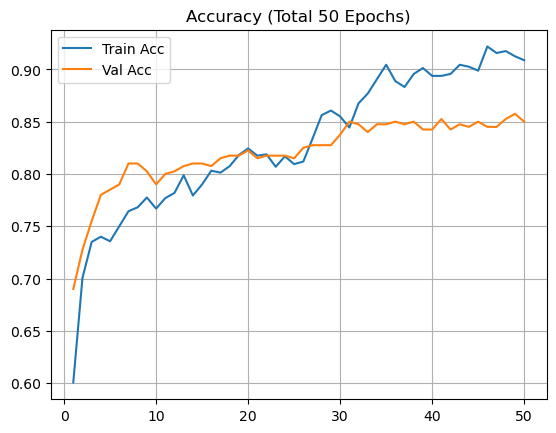

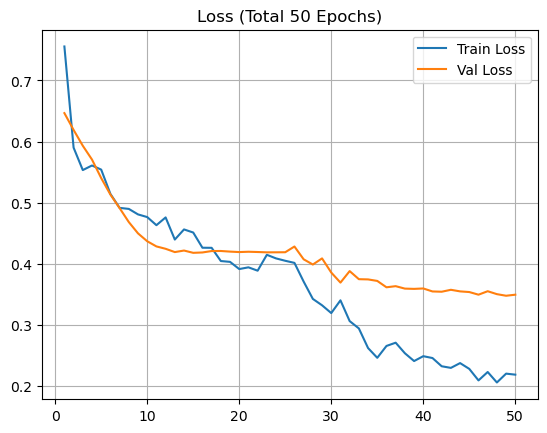

16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8680 - loss: 0.3201

Test Accuracy: 0.8679999709129333
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step


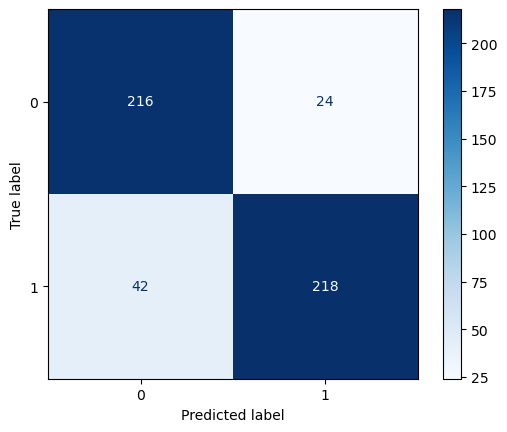


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       240
           1       0.90      0.84      0.87       260

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical

# =========================================
# 1. SETTINGS
# =========================================
PATH = "C:/Users/gsama/Desktop/mobinet"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 2

EPOCHS_STAGE1 = 25
EPOCHS_STAGE2 = 25   # TOTAL = 50

# =========================================
# 2. LOAD DATA
# =========================================
X = np.load(os.path.join(PATH, "X_train.npy"))
y = np.load(os.path.join(PATH, "y_train.npy"))

X_test = np.load(os.path.join(PATH, "X_test.npy"))
y_test = np.load(os.path.join(PATH, "y_test.npy"))

# =========================================
# 3. SPLIT
# =========================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 4. RGB → YCgCr
# =========================================
def rgb_to_ycgcr(img):
    img = img.astype("float32")

    R = img[:, :, :, 0]
    G = img[:, :, :, 1]
    B = img[:, :, :, 2]

    Y  = 0.25 * R + 0.50 * G + 0.25 * B
    Cg = -0.25 * R + 0.50 * G - 0.25 * B
    Cr = 0.50 * R - 0.50 * B

    return np.stack((Y, Cg, Cr), axis=-1)

X_train = rgb_to_ycgcr(X_train)
X_val   = rgb_to_ycgcr(X_val)
X_test  = rgb_to_ycgcr(X_test)

# =========================================
# 5. RESIZE
# =========================================
X_train = tf.image.resize(X_train, IMG_SIZE).numpy()
X_val   = tf.image.resize(X_val, IMG_SIZE).numpy()
X_test  = tf.image.resize(X_test, IMG_SIZE).numpy()

# =========================================
# 6. NORMALIZE
# =========================================
mean = np.mean(X_train, axis=(0,1,2), keepdims=True)
std  = np.std(X_train, axis=(0,1,2), keepdims=True) + 1e-7

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

# =========================================
# 7. LABELS
# =========================================
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

# =========================================
# 8. AUGMENTATION
# =========================================
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

# =========================================
# 9. MODEL
# =========================================
base_model = tf.keras.applications.VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = data_aug(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================
# 10. CALLBACKS
# =========================================
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg16_ycgcr.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# =========================================
# 11. STAGE 1 (25 epochs)
# =========================================
history_1 = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS_STAGE1,
    batch_size=BATCH_SIZE,
    callbacks=[reduce_lr, checkpoint],
    verbose=1
)

# =========================================
# 12. FINE-TUNE
# =========================================
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================
# 13. STAGE 2 (25 epochs)
# =========================================
history_2 = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS_STAGE2,
    batch_size=BATCH_SIZE,
    callbacks=[reduce_lr, checkpoint],
    verbose=1
)

# =========================================
# 14. COMBINE HISTORY
# =========================================
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

epochs_range = range(1, 51)

# =========================================
# 15. PLOTS
# =========================================
plt.plot(epochs_range, acc, label="Train Acc")
plt.plot(epochs_range, val_acc, label="Val Acc")
plt.title("Accuracy (Total 50 Epochs)")
plt.legend()
plt.grid()
plt.show()

plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.title("Loss (Total 50 Epochs)")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 16. TEST EVALUATION
# =========================================
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("\nTest Accuracy:", test_acc)

# =========================================
# 17. CONFUSION MATRIX
# =========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# =========================================
# 18. REPORT
# =========================================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))